In [31]:
from scripts import doppler, plotting
from scripts.corrections import bias, ionosphere, geometry
import matplotlib.pyplot as plt
import numpy as np

In [32]:
WIN_AZ = 512
WIN_RG = 256
STRIDE_AZ = 256
STRIDE_RG = 128

In [33]:
slc_path = 'data/Biomass_data/desert_scene/rfi1_filtered_desert_hh.slc'
slc_par_path = 'data/Biomass_data/desert_scene/BIO_dessert.hh.slc.par'
annot_path = 'data/Biomass_data/desert_scene/BIO_S2_SCS__1S_20260202T174434_20260202T174457_T_G01_M01_CDR_T026_F137_01_DMKLZR/annotation/bio_s2_scs__1s_20260202t174434_20260202t174457_t_g01_m01_cdr_t026_f137_annot.xml'
ionex_path='data/ionosphere/20260202/COD0OPSFIN_20260330000_01D_01H_GIM.INX'

In [34]:
dc_img_fft, freqs, spectrum = doppler.fft_doppler(slc_path, slc_par_path, WIN_AZ, WIN_RG, STRIDE_AZ, STRIDE_RG, smooth_sigma=2)

Text(0, 0.5, 'Power')

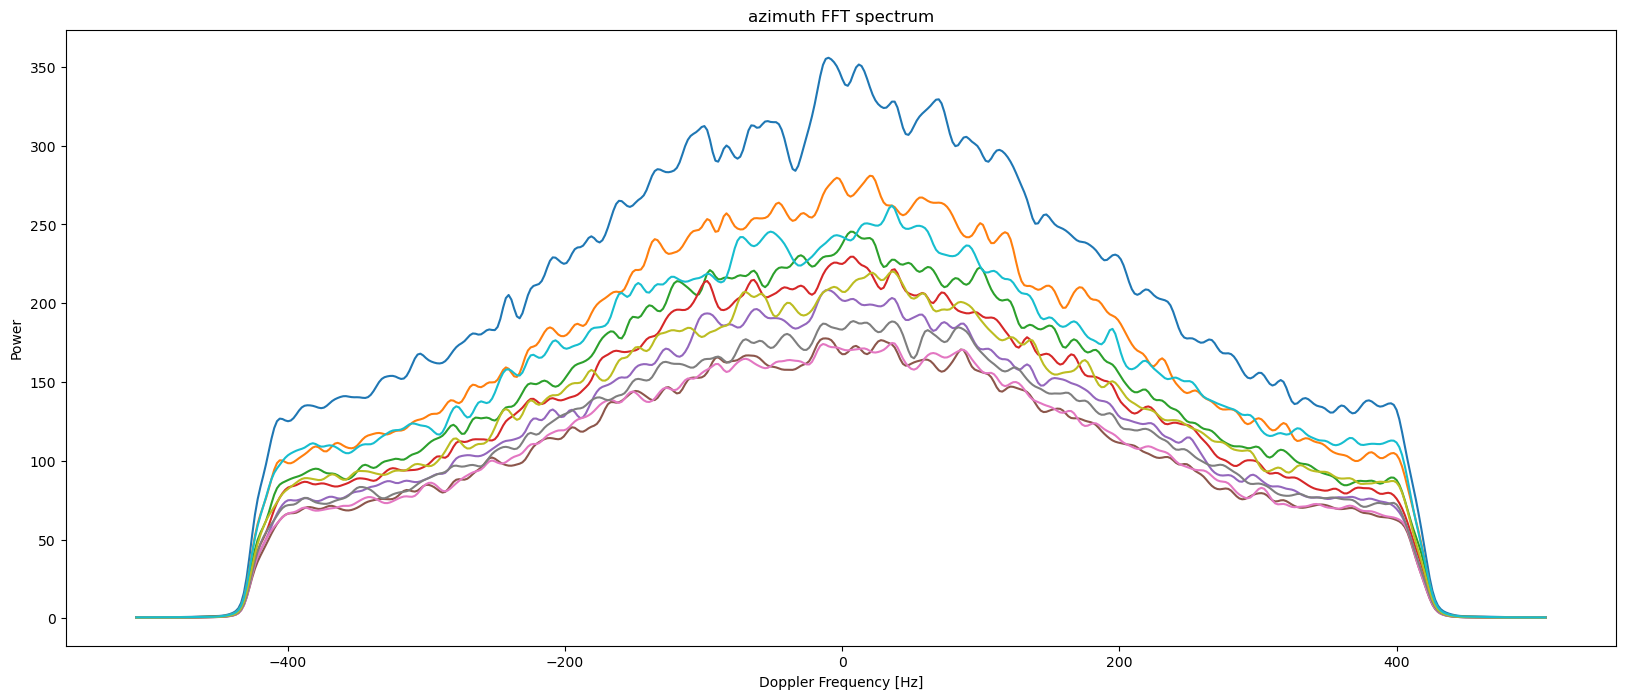

In [35]:
fig,ax = plt.subplots(1,1, figsize=(20,8))

for i in np.arange(1,11):
    ax.plot(freqs, spectrum[1,i])
ax.set_title("azimuth FFT spectrum")
ax.set_xlabel("Doppler Frequency [Hz]")
ax.set_ylabel("Power")

In [36]:
f_geom = geometry.estimate_geom_doppler_bio(annot_path, dc_img_fft)
f_iono = ionosphere.iono_doppler_correction(ionex_path, slc_par_path)

In [37]:
f_res = dc_img_fft - f_geom - f_iono

In [38]:
bias, _, _, mask = bias.compute_calibration_bias(f_res, spectrum, 1.5)

Text(0.5, 0, 'Bias: -1.73')

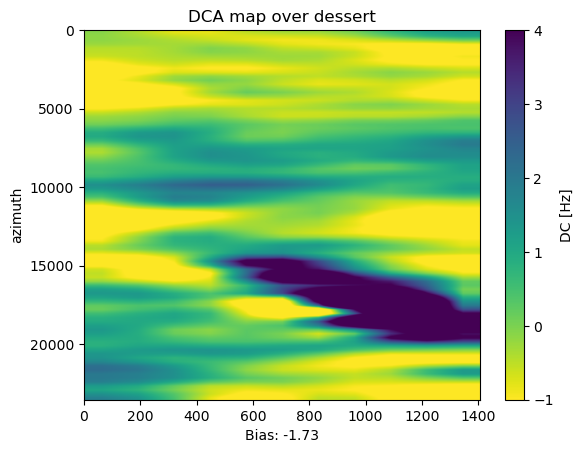

In [39]:
fig, ax = plt.subplots()
plotting.plot_dc_map(doppler.smooth_dc_map(f_res-bias, STRIDE_AZ, STRIDE_RG, 1, 1), ax=ax, title='DCA map over dessert')
ax.set_xlabel(f"Bias: {bias:.2f}")

In [40]:
slc_path = 'data/Biomass_data/test2/20260206.hh.slc'
slc_par_path = 'data/Biomass_data/test2/20260206.hh.slc.par'
annot_path = 'data/Biomass_data/test2/BIO_S2_SCS__1S_20260206T042117_20260206T042137_T_G01_M01_CDR_T032_F281_01_DMKUB5/annotation/bio_s2_scs__1s_20260206t042117_20260206t042137_t_g01_m01_cdr_t032_f281_annot.xml'
ionex_path= 'data/ionosphere/20260206/COD0OPSFIN_20260370000_01D_01H_GIM.INX'

In [41]:
dc_img_fft, freqs, spectrum = doppler.fft_doppler(slc_path, slc_par_path, WIN_AZ, WIN_RG, STRIDE_AZ, STRIDE_RG, smooth_sigma=2)

Text(0, 0.5, 'Power')

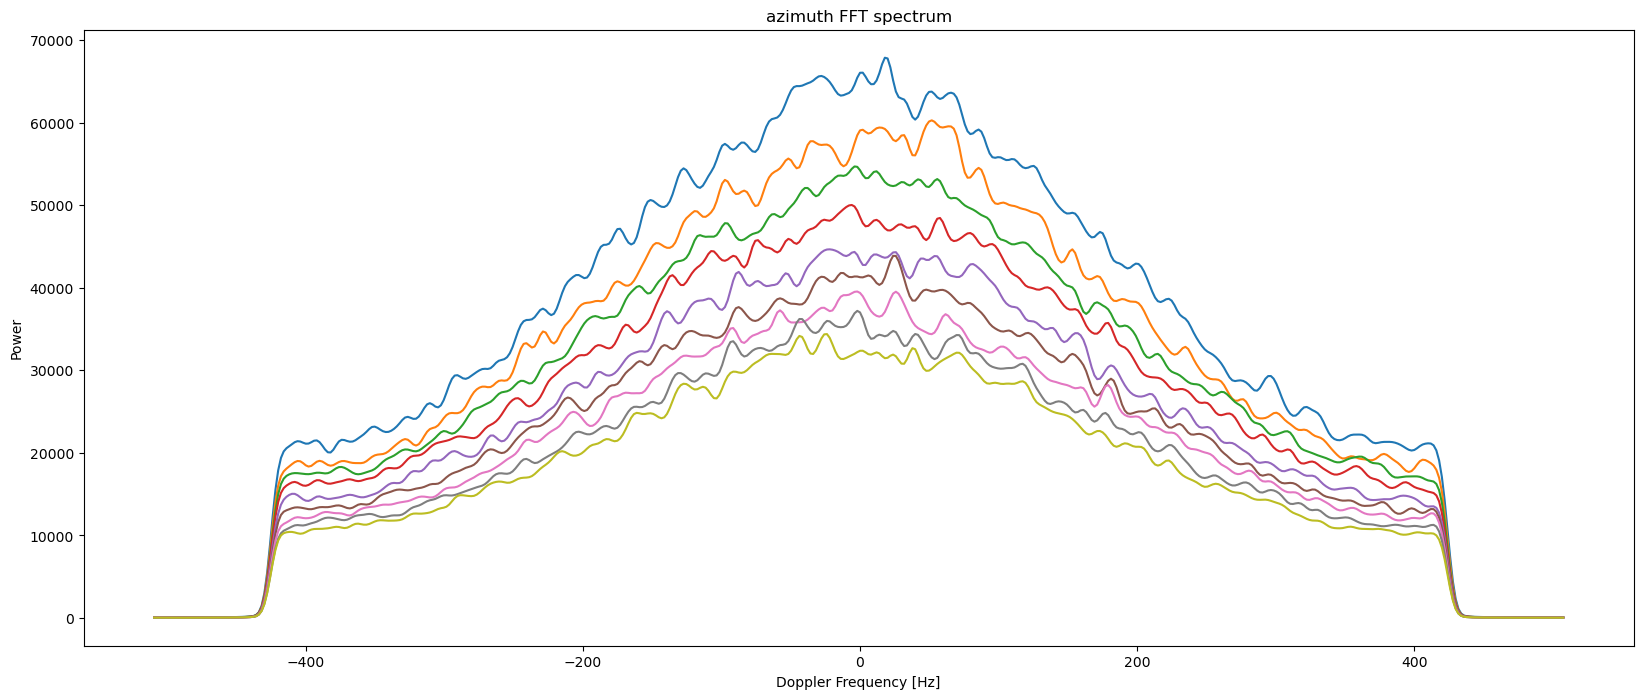

In [42]:
fig,ax = plt.subplots(1,1, figsize=(20,8))

for i in np.arange(1,10):
    ax.plot(freqs, spectrum[1,i])
ax.set_title("azimuth FFT spectrum")
ax.set_xlabel("Doppler Frequency [Hz]")
ax.set_ylabel("Power")

In [43]:
f_geom = geometry.estimate_geom_doppler_bio(annot_path, dc_img_fft)
f_iono = ionosphere.iono_doppler_correction(ionex_path, slc_par_path)

In [44]:
f_res = dc_img_fft - f_geom - f_iono

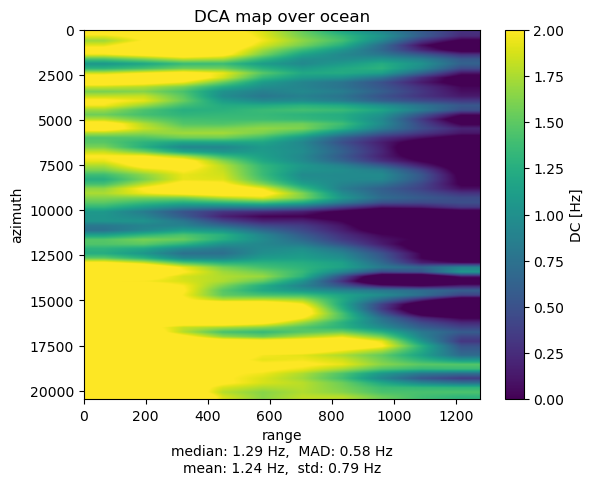

In [45]:
fig, ax = plt.subplots()
plotting.plot_dc_map(doppler.smooth_dc_map(f_res-bias, STRIDE_AZ, STRIDE_RG, 1, 1), ax=ax, title='DCA map over ocean', cmap='viridis')